<a href="https://colab.research.google.com/github/ShaoEH/ai-hw-spring-2026-aa/blob/main/ai_hw_spring_2026_aa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
class MNISTConvNet(nn.Module):
    def __init__(self):
        super(MNISTConvNet, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=5),
            nn.Dropout2d(p=0.2),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(32 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(-1, 32 * 4 * 4)
        logits = self.classifier(x)
        return logits

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = datasets.MNIST('./data', train=True, download=True, transform=mnist_transform)
test_set = datasets.MNIST('./data', train=False, transform=mnist_transform)

batch_size_train = 128
batch_size_test = 512

train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size_train, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size_test, shuffle=False)

In [16]:
model = MNISTConvNet().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
loss_function = nn.CrossEntropyLoss()

num_epochs = 5
model.train()

print("Starting model training...")
for epoch in range(1, num_epochs + 1):
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = loss_function(output, labels)
        loss.backward()
        optimizer.step()

        if batch_idx % 300 == 0:
            current_progress = batch_idx * len(images)
            total_size = len(train_loader.dataset)
            print(f"Train Epoch: {epoch} [{current_progress}/{total_size}] \tLoss: {loss.item():.6f}")

print("Training complete!")

Starting model training...
Train Epoch: 1 [0/60000] 	Loss: 2.328952
Train Epoch: 1 [38400/60000] 	Loss: 0.540697
Train Epoch: 2 [0/60000] 	Loss: 0.394961
Train Epoch: 2 [38400/60000] 	Loss: 0.244929
Train Epoch: 3 [0/60000] 	Loss: 0.284335
Train Epoch: 3 [38400/60000] 	Loss: 0.215508
Train Epoch: 4 [0/60000] 	Loss: 0.215524
Train Epoch: 4 [38400/60000] 	Loss: 0.120475
Train Epoch: 5 [0/60000] 	Loss: 0.049578
Train Epoch: 5 [38400/60000] 	Loss: 0.134145
Training complete!


In [17]:
def fgsm_attack(images, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_images = images + epsilon * sign_data_grad
    return torch.clamp(perturbed_images, 0, 1)

def pgd_attack(model, images, labels, eps, alpha, steps):
    adversarial_images = images.clone().detach().to(device)
    for _ in range(steps):
        adversarial_images.requires_grad = True
        outputs = model(adversarial_images)
        loss = loss_function(outputs, labels)
        model.zero_grad()
        loss.backward()

        adversarial_images = adversarial_images + alpha * adversarial_images.grad.sign()
        perturbation = torch.clamp(adversarial_images - images, min=-eps, max=eps)
        adversarial_images = torch.clamp(images + perturbation, min=0, max=1).detach()
    return adversarial_images

def mifgsm_attack(model, images, labels, eps, alpha, steps, decay_factor):
    adversarial_images = images.clone().detach().to(device)
    momentum = torch.zeros_like(images).detach().to(device)
    for _ in range(steps):
        adversarial_images.requires_grad = True
        outputs = model(adversarial_images)
        loss = loss_function(outputs, labels)
        model.zero_grad()
        loss.backward()

        grad = adversarial_images.grad.data
        grad_norm = torch.norm(grad.view(grad.shape[0], -1), p=1, dim=1).view(-1, 1, 1, 1)
        grad_norm = torch.clamp(grad_norm, min=1e-8)
        grad = grad / grad_norm

        momentum = decay_factor * momentum + grad
        adversarial_images = adversarial_images + alpha * momentum.sign()

        perturbation = torch.clamp(adversarial_images - images, min=-eps, max=eps)
        adversarial_images = torch.clamp(images + perturbation, min=0, max=1).detach()
    return adversarial_images

In [18]:
std = 0.3081
epsilon = 0.3 / std
step_size = 0.02 / std
num_steps = 20
momentum_decay = 1.0

model.eval()
clean_correct_count = 0
total_samples = 0
fgsm_success_count, pgd_success_count, mifgsm_success_count = 0, 0, 0

print(f"Testing with normalized epsilon: {epsilon:.4f}")
print("Starting adversarial attack testing...")

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    total_samples += labels.size(0)

    outputs = model(images)
    initial_predictions = outputs.max(1, keepdim=True)[1]

    correct_mask = initial_predictions.squeeze() == labels
    clean_correct_count += correct_mask.sum().item()

    if correct_mask.sum().item() == 0:
        continue

    correct_images = images[correct_mask].detach().requires_grad_(True)
    correct_labels = labels[correct_mask]
    correct_outputs = model(correct_images)

    # FGSM Attack
    loss = loss_function(correct_outputs, correct_labels)
    model.zero_grad()
    loss.backward()
    adv_images_fgsm = fgsm_attack(correct_images, epsilon, correct_images.grad.data)
    predictions_fgsm = model(adv_images_fgsm).max(1, keepdim=True)[1]
    fgsm_success_count += (predictions_fgsm.squeeze() != correct_labels).sum().item()

    # PGD Attack
    adv_images_pgd = pgd_attack(model, correct_images, correct_labels, epsilon, step_size, num_steps)
    predictions_pgd = model(adv_images_pgd).max(1, keepdim=True)[1]
    pgd_success_count += (predictions_pgd.squeeze() != correct_labels).sum().item()

    # MI-FGSM Attack
    adv_images_mifgsm = mifgsm_attack(model, correct_images, correct_labels, epsilon, step_size, num_steps, momentum_decay)
    predictions_mifgsm = model(adv_images_mifgsm).max(1, keepdim=True)[1]
    mifgsm_success_count += (predictions_mifgsm.squeeze() != correct_labels).sum().item()

clean_accuracy = clean_correct_count / total_samples
print(f"\n===== Adjusted Test Results =====")
print(f"Clean Accuracy: {clean_accuracy * 100:.2f}%")
print(f"FGSM ASR: {(fgsm_success_count / clean_correct_count) * 100:.2f}%")
print(f"PGD ASR: {(pgd_success_count / clean_correct_count) * 100:.2f}%")
print(f"MI-FGSM ASR: {(mifgsm_success_count / clean_correct_count) * 100:.2f}%")

Testing with normalized epsilon: 0.9737
Starting adversarial attack testing...

===== Adjusted Test Results =====
Clean Accuracy: 97.96%
FGSM ASR: 88.47%
PGD ASR: 99.54%
MI-FGSM ASR: 99.11%


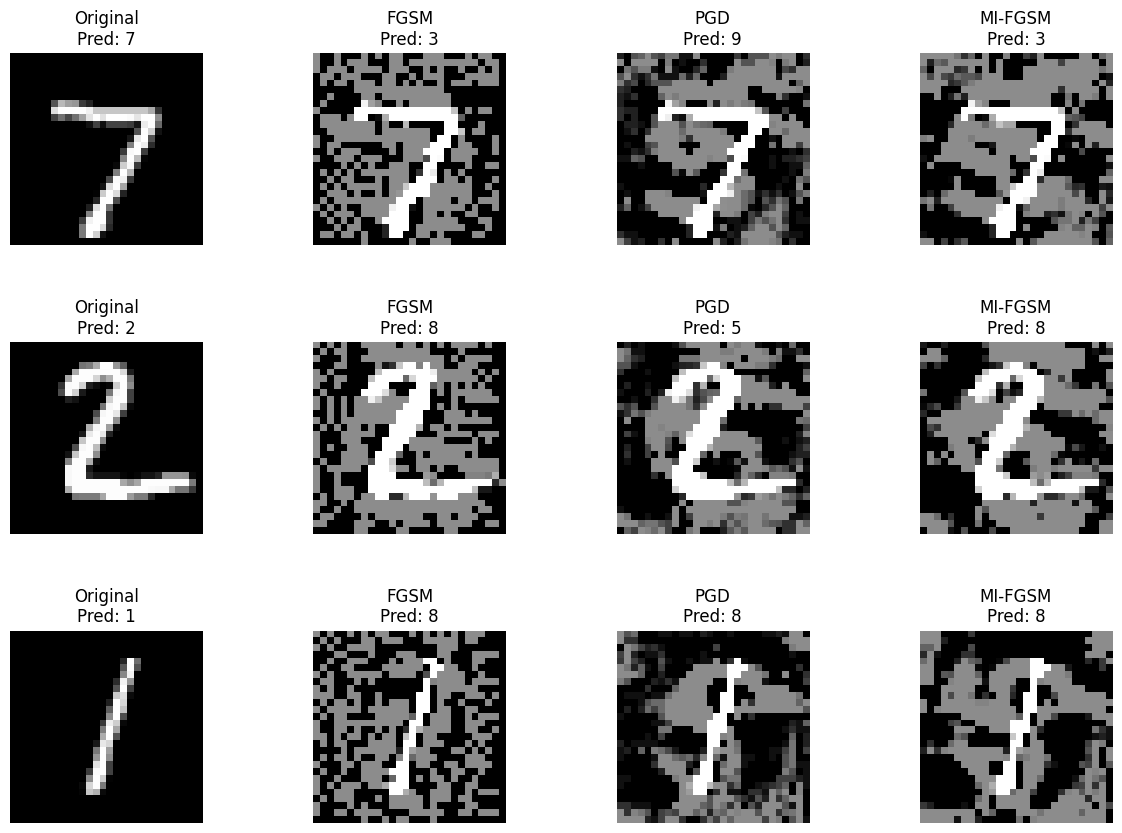

In [19]:
def visualize_attacks(model, images, labels, epsilon, step_size, num_steps, momentum_decay):
    model.eval()
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    init_preds = outputs.max(1, keepdim=True)[1].squeeze()
    correct_indices = (init_preds == labels).nonzero(as_tuple=True)[0]

    indices_to_show = correct_indices[:3]

    fig, axes = plt.subplots(len(indices_to_show), 4, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.5)

    for i, idx in enumerate(indices_to_show):
        img = images[idx:idx+1].detach().requires_grad_(True)
        label = labels[idx:idx+1]

        output = model(img)
        loss = loss_function(output, label)
        model.zero_grad()
        loss.backward()

        adv_fgsm = fgsm_attack(img, epsilon, img.grad.data)
        adv_pgd = pgd_attack(model, img, label, epsilon, step_size, num_steps)
        adv_mifgsm = mifgsm_attack(model, img, label, epsilon, step_size, num_steps, momentum_decay)

        attack_list = [img, adv_fgsm, adv_pgd, adv_mifgsm]
        titles = ['Original', 'FGSM', 'PGD', 'MI-FGSM']

        for j, adv_img in enumerate(attack_list):
            pred = model(adv_img).max(1, keepdim=True)[1].item()

            display_img = adv_img.squeeze().detach().cpu().numpy()
            display_img = (display_img * 0.3081) + 0.1307

            axes[i, j].imshow(display_img, cmap='gray')
            axes[i, j].set_title(f"{titles[j]}\nPred: {pred}")
            axes[i, j].axis('off')

    plt.show()

images, labels = next(iter(test_loader))
visualize_attacks(model, images, labels, epsilon, step_size, num_steps, momentum_decay)